In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from src.data_loader import load_data
from src.eda_utils import *

pd.set_option("display.max_columns", None)

In [5]:
df = load_data("../data/insurance_data.csv")

df.head()

,"CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate"
0,"AC-100000,56,Male,Addis Ababa,Sedan,147270,61,..."
1,"AC-100001,69,Female,Addis Ababa,SUV,74640,57,2..."
2,"AC-100002,46,Male,Oromia,Sedan,70555,42,1697,2..."
3,"AC-100003,32,Female,Somali,Sedan,89398,63,2370..."
4,"AC-100004,60,Female,Tigray,SUV,78475,69,2582,5..."


In [6]:
df.shape

(10000, 1)

In [7]:
df.dtypes

CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate    str
dtype: object

In [8]:
df.describe()

,"CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate"
count,10000
unique,10000
top,"AC-100000,56,Male,Addis Ababa,Sedan,147270,61,..."
freq,1


In [9]:
df.isnull().sum().sort_values(ascending=False)

CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate    0
dtype: int64

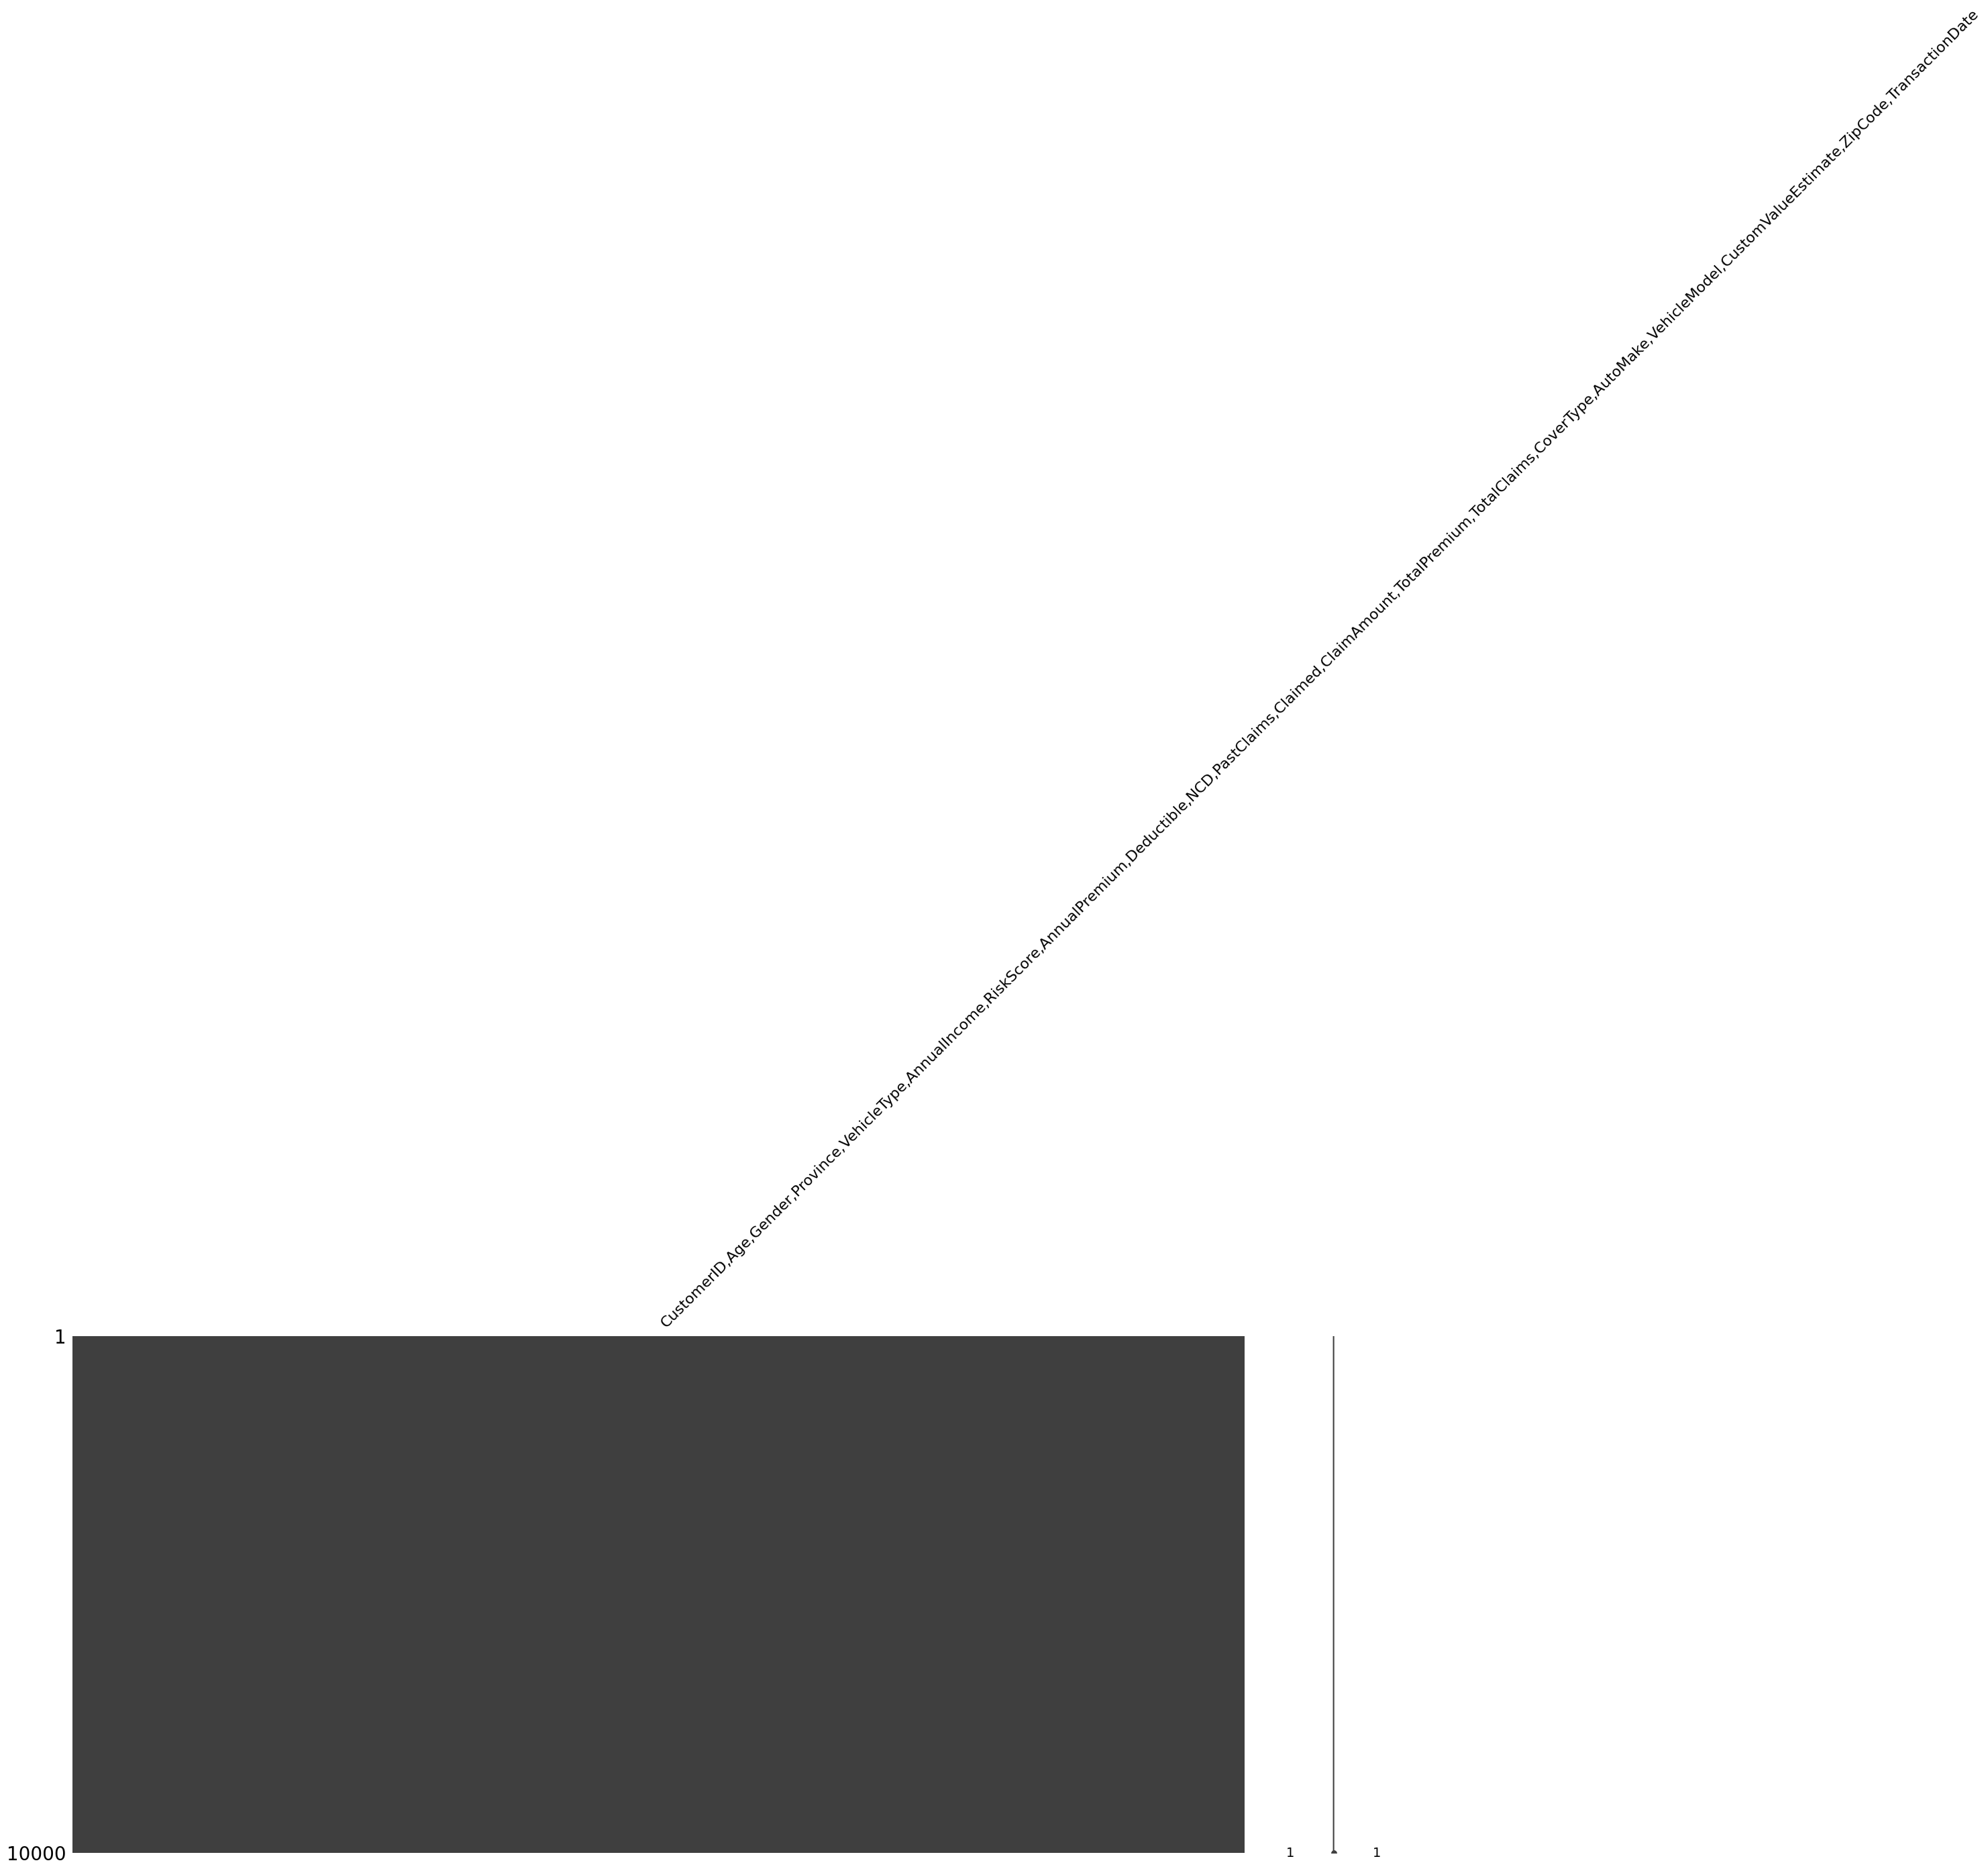

In [10]:
msno.matrix(df)
plt.show()

"""
- Numerical missing values:
    fill with median

- Categorical missing values:
    fill with mode

- Columns with too many missing values:
    may be dropped
"""

In [14]:
df.columns = df.columns.str.strip()

In [15]:
print(df.columns.tolist())

['CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate']


In [19]:
df = pd.read_csv("../data/insurance_data.csv")

In [20]:
overall_loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()

overall_loss_ratio

np.float64(0.5281836596904845)

In [21]:
print(f"Overall portfolio loss ratio: {overall_loss_ratio:.2f}")

Overall portfolio loss ratio: 0.53


In [22]:
province_analysis = df.groupby("Province")[["TotalClaims", "TotalPremium"]].sum()

province_analysis["LossRatio"] = (
    province_analysis["TotalClaims"] /
    province_analysis["TotalPremium"]
)

province_analysis.sort_values("LossRatio", ascending=False)

,TotalClaims,TotalPremium,LossRatio
Province,,,
Somali,1826593.0,2984984,0.611927
Oromia,3261061.0,6069663,0.537272
Tigray,1047136.0,1990692,0.526016
Addis Ababa,4653210.0,8907374,0.522400
Amhara,2353885.0,4928566,0.477600


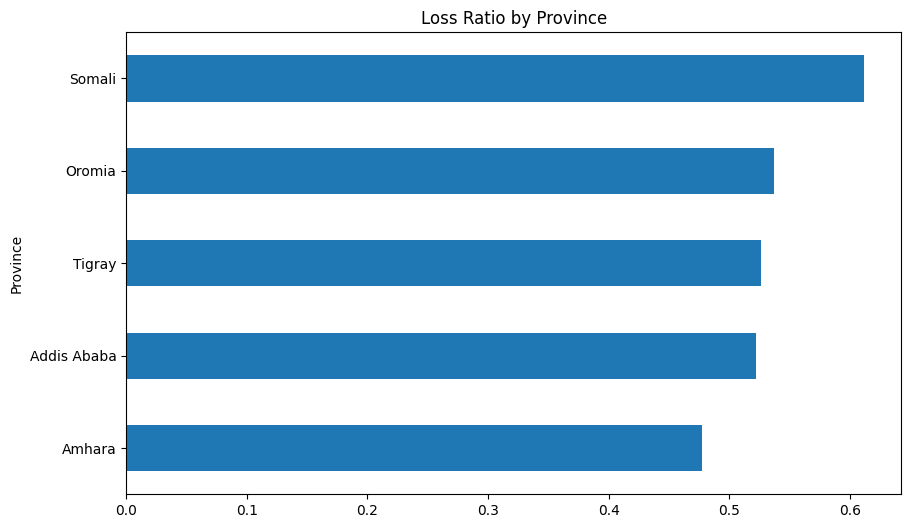

In [23]:
province_analysis["LossRatio"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Loss Ratio by Province")
plt.show()

In [24]:
gender_analysis = df.groupby("Gender")[["TotalClaims", "TotalPremium"]].sum()

gender_analysis["LossRatio"] = (
    gender_analysis["TotalClaims"] /
    gender_analysis["TotalPremium"]
)

gender_analysis

,TotalClaims,TotalPremium,LossRatio
Gender,,,
Female,6763030.0,12791141,0.528728
Male,6378855.0,12090138,0.527608


In [25]:
vehicle_analysis = df.groupby("VehicleType")[["TotalClaims", "TotalPremium"]].sum()

vehicle_analysis["LossRatio"] = (
    vehicle_analysis["TotalClaims"] /
    vehicle_analysis["TotalPremium"]
)

vehicle_analysis.sort_values("LossRatio", ascending=False)

,TotalClaims,TotalPremium,LossRatio
VehicleType,,,
Luxury,3569207.0,4236839,0.842422
SUV,4090665.0,7256436,0.563729
Hatchback,1904235.0,4532134,0.420163
Sedan,3577778.0,8855870,0.404001


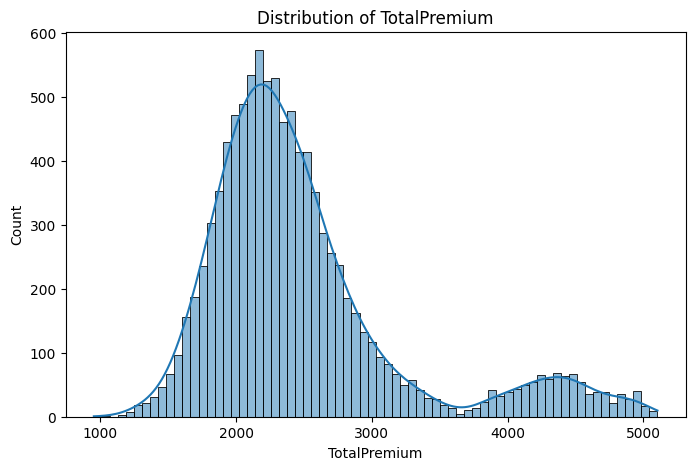

In [26]:
plot_histogram(df, "TotalPremium")

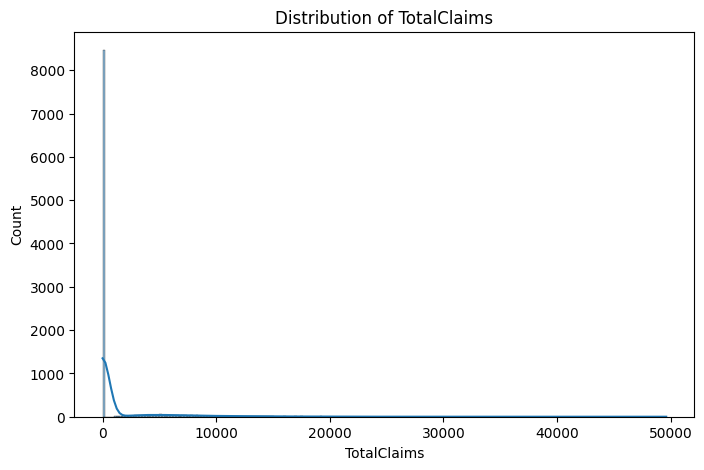

In [27]:
plot_histogram(df, "TotalClaims")

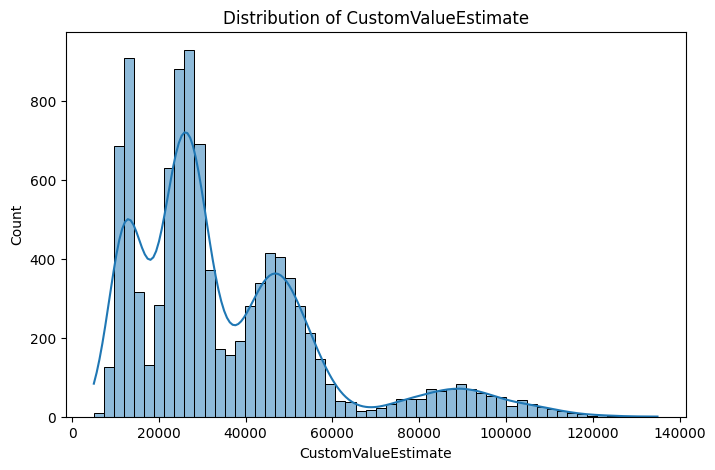

In [28]:
plot_histogram(df, "CustomValueEstimate")

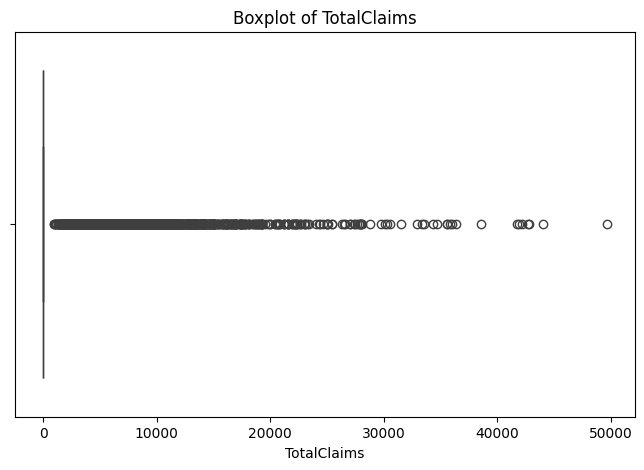

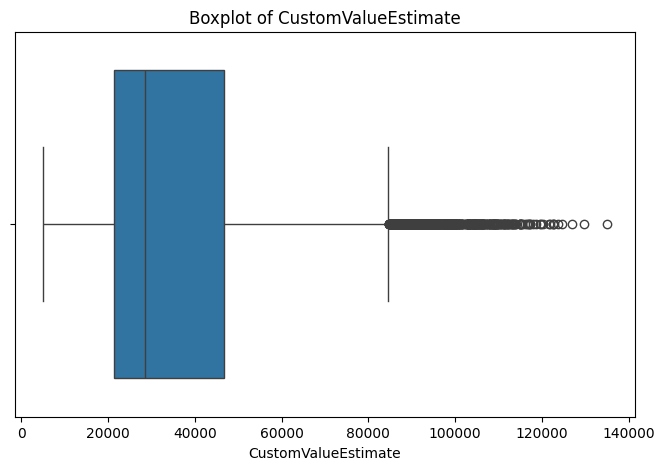

In [29]:
plot_boxplot(df, "TotalClaims")
plot_boxplot(df, "CustomValueEstimate")

"""
Observation:
Several extreme outliers exist in TotalClaims,
indicating a small number of very expensive claims.
"""

In [31]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionDate"]).dt.to_period("M")

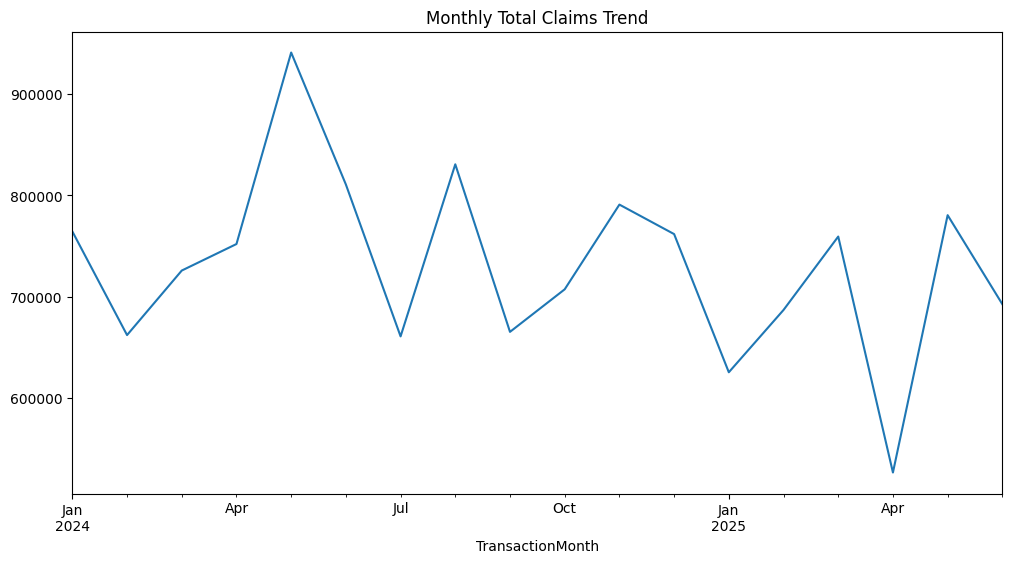

In [32]:
monthly_claims = df.groupby("TransactionMonth")["TotalClaims"].sum()

monthly_claims.plot(figsize=(12,6))

plt.title("Monthly Total Claims Trend")
plt.show()

In [34]:
col = 'Make' if 'Make' in df.columns else ('AutoMake' if 'AutoMake' in df.columns else None)
if col is None:
    raise KeyError(f"Expected 'Make' or 'AutoMake' column in df.columns, got: {df.columns.tolist()}")
top_claims = df.groupby(col)["TotalClaims"].sum().sort_values(ascending=False)

top_claims.head(10)

AutoMake
Toyota           4503241.0
Hyundai          3207466.0
Suzuki           1916420.0
Mercedes-Benz    1200483.0
Lifan            1174255.0
BMW              1140020.0
Name: TotalClaims, dtype: float64

In [35]:
top_claims.tail(10)

AutoMake
Toyota           4503241.0
Hyundai          3207466.0
Suzuki           1916420.0
Mercedes-Benz    1200483.0
Lifan            1174255.0
BMW              1140020.0
Name: TotalClaims, dtype: float64

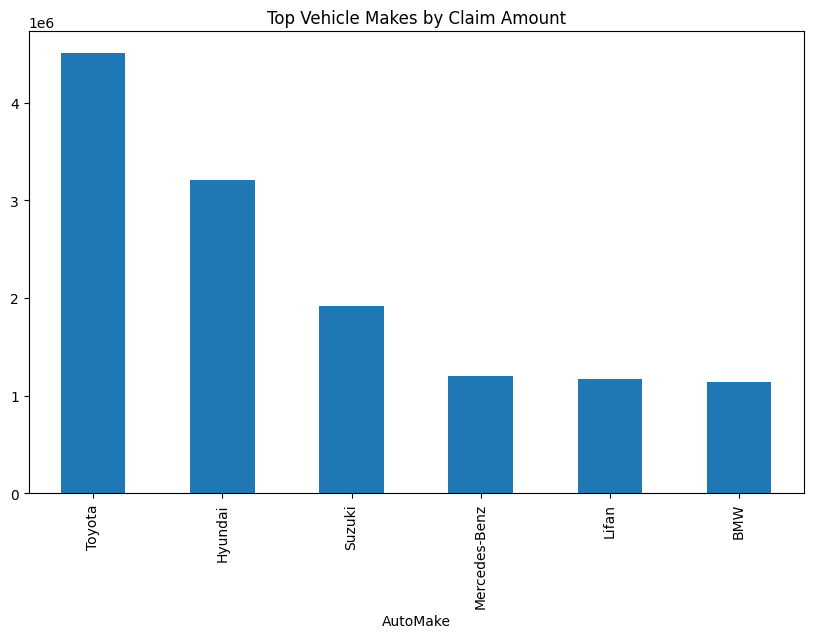

In [36]:
top_claims.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top Vehicle Makes by Claim Amount")
plt.show()

In [37]:
numeric_df = df.select_dtypes(include=np.number)

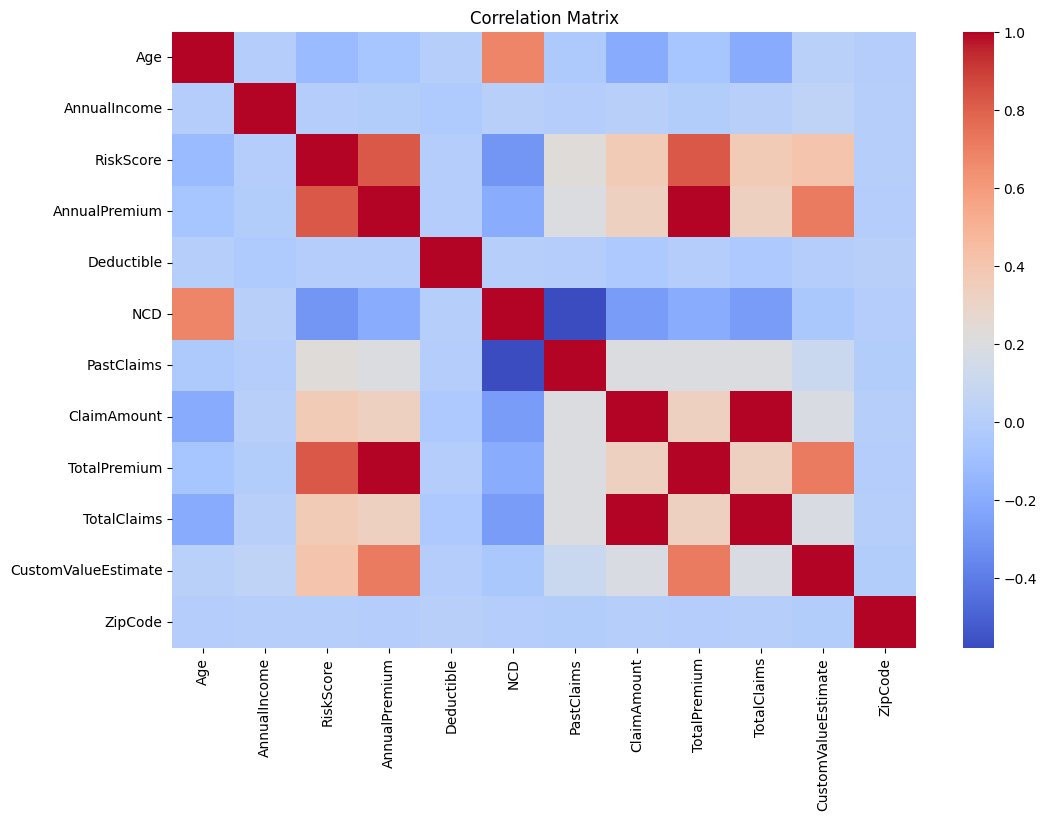

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

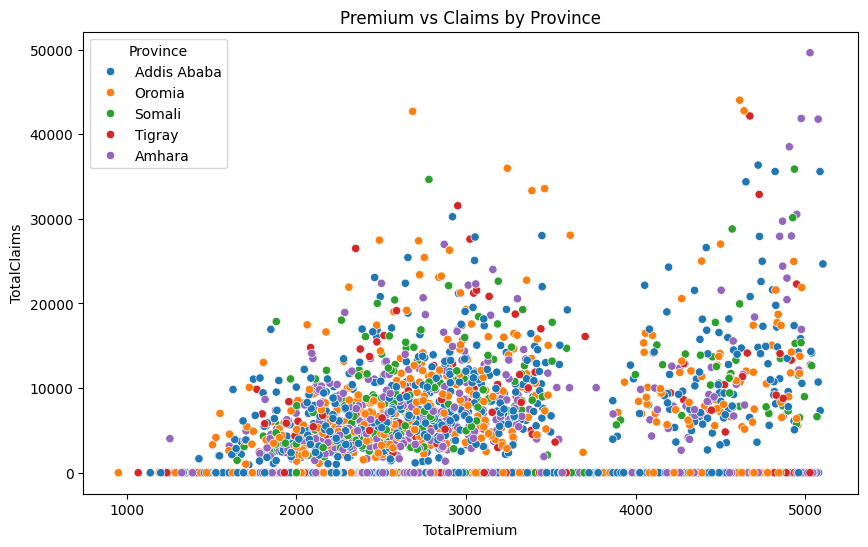

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

plt.title("Premium vs Claims by Province")

plt.show()

"""
Insight:
Gauteng and Western Cape show relatively higher
claim activity compared to other provinces.
"""

In [3]:
import pandas as pd

try:
    cleaned_df = df.copy()
except NameError:
    cleaned_df = pd.read_csv("../data/insurance_data.csv")

cleaned_df = cleaned_df.drop_duplicates()
cleaned_df = cleaned_df.fillna(0)

cleaned_df = cleaned_df.drop_duplicates()

cleaned_df = cleaned_df.fillna(0)

NameError: name 'pd' is not defined

In [ ]:
cleaned_df.to_csv(
    "../data/insurance_data_cleaned.csv",
    index=False
)